<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/Bidirectional_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras. layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense

In [ ]:
vocab_size=10000
max_length=200
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
X_train=pad_sequences(X_train,maxlen=max_length)
X_test=pad_sequences(X_test,maxlen=max_length)
print("Training Shape",X_train. shape, X_test.shape)

Training Shape (25000, 200) (25000, 200)


Common Triaining Function

In [ ]:
def train_model(model, model_name):

  start_time = time.time()
  model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
  )
  history = model.fit(
  X_train,
  y_train,
  validation_split=0.2,
  epochs=3,
  batch_size=128,
  verbose=1
  )
  loss, accuracy = model.evaluate(
  X_test,
  y_test,
  verbose=0

  )

  training_time = time.time() - start_time

  print("\n" + "="*50)
  print(model_name)
  print("Accuracy:", accuracy)
  print("Training Time :", training_time)

  return accuracy, training_time, history

# Model 1 - Simple RNN

In [ ]:
simple_rnn=Sequential([
Embedding(vocab_size,64),
SimpleRNN(64),
Dense(1,activation='sigmoid')
])
rnn_acc,rnn_time,rnn_history=train_model(simple_rnn, 'SimpleRNN')

simple_rnn.summary()

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.5964 - loss: 0.6544 - val_accuracy: 0.6656 - val_loss: 0.5908
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8252 - loss: 0.3956 - val_accuracy: 0.7994 - val_loss: 0.4501
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9183 - loss: 0.2108 - val_accuracy: 0.8140 - val_loss: 0.4542

SimpleRNN
Accuracy: 0.8148000240325928
Training Time : 22.273642778396606


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,944,965 (7.42 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,296,644 (4.95 MB)

# Model 2 - Bidirectional LSTM

In [ ]:
lstm_model=Sequential([
Embedding(vocab_size,64),
LSTM(64),
Dense(1,activation='sigmoid')
])
lstm_model. summary()
lstm_acc, lstm_time, lstm_history=train_model(lstm_model, 'LSTM')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7308 - loss: 0.5147 - val_accuracy: 0.8440 - val_loss: 0.3598
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8941 - loss: 0.2668 - val_accuracy: 0.8736 - val_loss: 0.3083
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9299 - loss: 0.1876 - val_accuracy: 0.8744 - val_loss: 0.3239

LSTM
Accuracy: 0.866159975528717
Training Time : 14.114571571350098


# Model 3 - Bidirectional GRU

In [ ]:
gru_model=Sequential([
Embedding(vocab_size,64),
GRU(64),
Dense(1,activation='sigmoid')
])
gru_model. summary()

gru_acc,gru_time, gru_history=train_model(gru_model, 'GRU')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7139 - loss: 0.5349 - val_accuracy: 0.8446 - val_loss: 0.3655
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8847 - loss: 0.2851 - val_accuracy: 0.8436 - val_loss: 0.3591
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9183 - loss: 0.2111 - val_accuracy: 0.8594 - val_loss: 0.3613

GRU
Accuracy: 0.8449599742889404
Training Time : 13.50322961807251


# Model 4 - Bidirectional LSTM(BiLstm)

In [ ]:
bilstm_model=Sequential([
Embedding(vocab_size,64),
Bidirectional(LSTM(64)),
Dense(1,activation='sigmoid')

])

bilstm_model.summary()

bilstm_acc,bilstm_time,bilstm_history=train_model(bilstm_model, 'BiLSTM')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7560 - loss: 0.4823 - val_accuracy: 0.8430 - val_loss: 0.3732
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8916 - loss: 0.2741 - val_accuracy: 0.8664 - val_loss: 0.3071
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9246 - loss: 0.2004 - val_accuracy: 0.8642 - val_loss: 0.3415

BiLSTM
Accuracy: 0.859279990196228
Training Time : 23.420151948928833


# Model 5 - Bidirectional GRU(BiGRU)

In [ ]:
bigru_model=Sequential([
Embedding(vocab_size,64),
Bidirectional(GRU(64)),
Dense(1,activation='sigmoid')
])
bigru_model.summary()

bigru_acc,bigru_time,bigru_history=train_model(bigru_model, 'BiGRU')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6850 - loss: 0.5638 - val_accuracy: 0.8206 - val_loss: 0.4320
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8744 - loss: 0.3034 - val_accuracy: 0.8398 - val_loss: 0.3645
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9119 - loss: 0.2267 - val_accuracy: 0.8658 - val_loss: 0.3360

BiGRU
Accuracy: 0.8587200045585632
Training Time : 20.612969160079956


Comparison Table

In [ ]:
results=pd.DataFrame({
'Model':['SimpleRNN','LSTM', 'GRU', 'BiLSTM','BiGRU'],
'Accuracy': [rnn_acc, lstm_acc, gru_acc, bilstm_acc, bigru_acc],
'Training Time': [rnn_time, lstm_time, gru_time, bilstm_time,bigru_time]
})

results=results.sort_values(by='Accuracy',ascending=False)

print(results)

       Model  Accuracy  Training Time
1       LSTM   0.86616      14.114572
3     BiLSTM   0.85928      23.420152
4      BiGRU   0.85872      20.612969
2        GRU   0.84496      13.503230
0  SimpleRNN   0.81480      22.273643


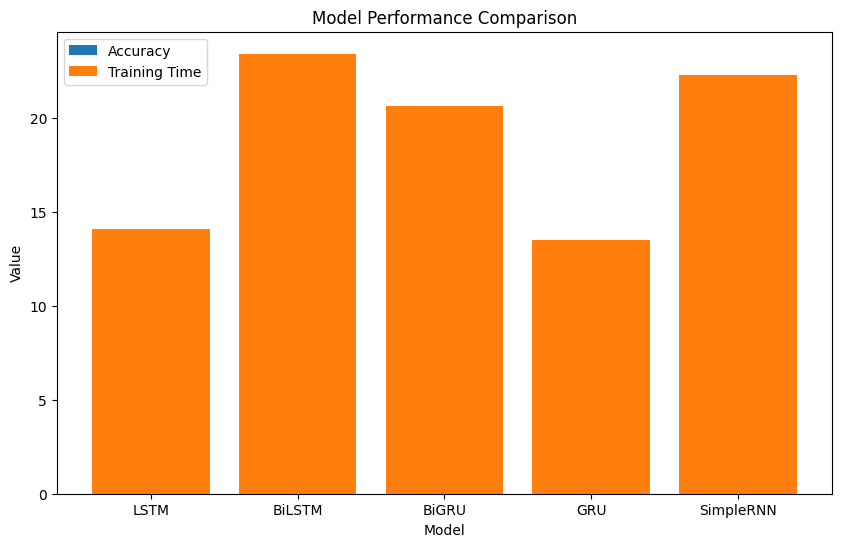

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results['Model'],results['Accuracy'],label='Accuracy')
plt.bar(results['Model'],results['Training Time'], label='Training Time')

plt.xlabel('Model')
plt.ylabel('Value')
plt.title('Model Performance Comparison')
plt.legend()

plt.show()
